best k by silhouette: 7
----------------------------------------
student group summary:
       maths  english  science  attendance  assignments
group                                                  
0       58.6     55.2     42.9        87.6          6.0
1       80.8     65.7     53.0        67.7          1.7
2       73.8     85.1     84.3        59.5          4.7
3       40.7     62.5     52.4        70.5          1.8
4       54.3     71.7     83.7        86.0          7.1
5       72.9     52.3     82.3        90.1          1.4
6       72.6     47.0     60.0        61.8          7.3
----------------------------------------
students per group:
group
3    26
1    23
2    23
4    23
0    21
5    18
6    16
Name: count, dtype: int64


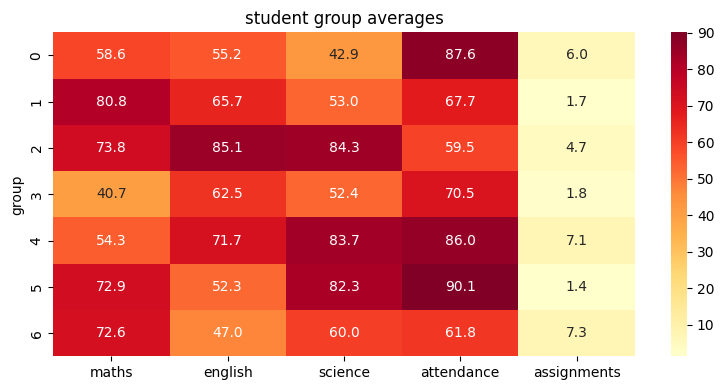

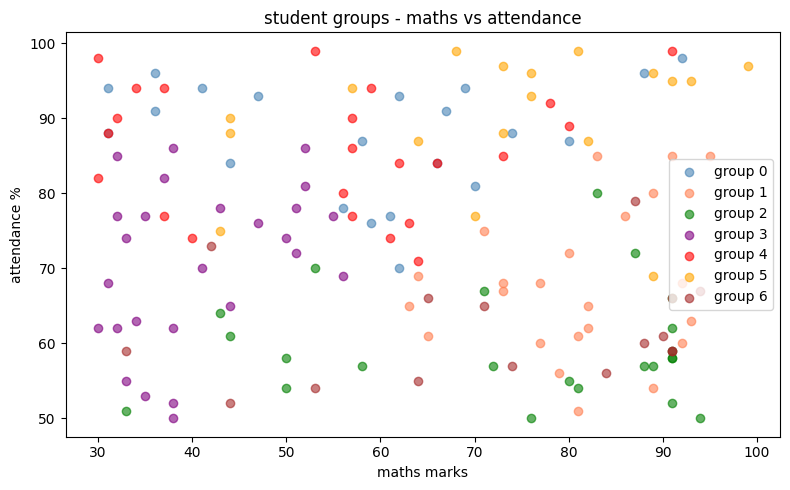

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 150

data = {
    "maths":      np.random.randint(30, 100, n),
    "english":    np.random.randint(30, 100, n),
    "science":    np.random.randint(30, 100, n),
    "attendance": np.random.randint(50, 100, n),
    "assignments":np.random.randint(0, 10, n)
}

df = pd.DataFrame(data)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

sil_scores = []
for k in range(2, 8):
    m = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = m.fit_predict(x_scaled)
    sil_scores.append(silhouette_score(x_scaled, labels))

best_k = sil_scores.index(max(sil_scores)) + 2
print("best k by silhouette:", best_k)

model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["group"] = model.fit_predict(x_scaled)

print("-" * 40)
print("student group summary:")
summary = df.groupby("group").mean().round(1)
print(summary)

print("-" * 40)
print("students per group:")
print(df["group"].value_counts())

plt.figure(figsize=(8, 4))
sns.heatmap(summary, annot=True, cmap="YlOrRd", fmt=".1f")
plt.title("student group averages")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
colors = ["steelblue", "coral", "green", "purple", "red", "orange", "brown"]
for i in range(best_k):
    cluster = df[df["group"] == i]
    plt.scatter(cluster["maths"], cluster["attendance"],
                c=colors[i], label="group " + str(i), alpha=0.6)

plt.title("student groups - maths vs attendance")
plt.xlabel("maths marks")
plt.ylabel("attendance %")
plt.legend()
plt.tight_layout()
plt.show()